In [106]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Embedding
import os
import matplotlib.pyplot as plt
import re
import shutil
import string
from tensorflow.keras import losses
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from keras.utils import to_categorical

from keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding,BatchNormalization, Flatten
from tensorflow.keras.layers import Input, GlobalAveragePooling1D
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import nltk
nltk.download('punkt')

from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

import spacy


print(tf.__version__)

2.18.0


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [88]:
!python -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 20.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [89]:
# Upload master dataset
master_df = pd.read_csv('Raw Master Data.csv')
master_df.head(10)

,LABEL,Content
0,universal healthcare,universal basic income offers strings attached...
1,universal healthcare,universal basic income politically controversi...
2,universal healthcare,senators grilled robert kennedy trump pick hea...
3,universal healthcare,health secretary says reform poverty ambition ...
4,universal healthcare,initiative follows pressure from several artis...
5,universal healthcare,lego prosthetic empowers year with affordable ...
6,universal healthcare,jerry said unilaterally barred from sharing po...
7,universal healthcare,chappell roan used grammy best artist speech d...
8,universal healthcare,thursday morning senate voted favor trump nomi...
9,universal healthcare,here what openai about trends this year just m...


In [90]:
# Check data types
master_df.dtypes

,0
LABEL,object
Content,object


In [91]:
# Remove words less than 3 characters from dataset
# using character length

def big_words(text):
  cleaner = " ".join([word for word in text.split() if len(word) >= 3])
  return cleaner

In [92]:
# Use function on data
master_df['Content'] = master_df['Content'].astype(str).apply(big_words)

In [93]:
# check results
master_df.head(10)

,LABEL,Content
0,universal healthcare,universal basic income offers strings attached...
1,universal healthcare,universal basic income politically controversi...
2,universal healthcare,senators grilled robert kennedy trump pick hea...
3,universal healthcare,health secretary says reform poverty ambition ...
4,universal healthcare,initiative follows pressure from several artis...
5,universal healthcare,lego prosthetic empowers year with affordable ...
6,universal healthcare,jerry said unilaterally barred from sharing po...
7,universal healthcare,chappell roan used grammy best artist speech d...
8,universal healthcare,thursday morning senate voted favor trump nomi...
9,universal healthcare,here what openai about trends this year just m...


In [94]:
# Actually, going to use pre-tokenized data instead, from Master Data Creation
token_df = pd.read_csv('StemmedData.csv')
token_df.head()

,Tokens,Stemmed,LABEL
0,"['universal', 'basic', 'income', 'offers', 'st...","['univers', 'basic', 'incom', 'offer', 'string...",universal healthcare
1,"['universal', 'basic', 'income', 'politically'...","['univers', 'basic', 'incom', 'polit', 'contro...",universal healthcare
2,"['senators', 'grilled', 'robert', 'kennedy', '...","['senat', 'grill', 'robert', 'kennedi', 'trump...",universal healthcare
3,"['health', 'secretary', 'says', 'reform', 'pov...","['health', 'secretari', 'say', 'reform', 'pove...",universal healthcare
4,"['initiative', 'follows', 'pressure', 'several...","['initi', 'follow', 'pressur', 'sever', 'artis...",universal healthcare


In [95]:
# Remove Stemmed Column
token_df = token_df.drop(columns = ['Stemmed'])
token_df.head()

,Tokens,LABEL
0,"['universal', 'basic', 'income', 'offers', 'st...",universal healthcare
1,"['universal', 'basic', 'income', 'politically'...",universal healthcare
2,"['senators', 'grilled', 'robert', 'kennedy', '...",universal healthcare
3,"['health', 'secretary', 'says', 'reform', 'pov...",universal healthcare
4,"['initiative', 'follows', 'pressure', 'several...",universal healthcare


In [96]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(token_df['Tokens'].apply(lambda x: ' '.join(x)))

In [97]:
# create sequences from tokenizer data, then pad them for equal length inputs
sequences = tokenizer.texts_to_sequences(token_df['Tokens'].apply(lambda x: ' '.join(x)))


padding = pad_sequences(sequences, padding = 'post', maxlen = 100)



In [98]:
# Encode labels
MyEncoder = LabelEncoder()

WordLabels= MyEncoder.fit_transform(token_df['LABEL'])

In [99]:
EncodeLabels = to_categorical(WordLabels) # One hot encode the results

In [100]:
print(len(tokenizer.word_index))

39


In [101]:
# Now create a training/testing dataset split
Training_Data, Testing_Data, Training_Label, Testing_Label = train_test_split(padding, EncodeLabels, test_size = 0.4, random_state = 340,)


# check results
print('Training Data:', Training_Data)
print('Training Labels:', Training_Label)

print('Testing Data:', Testing_Data)
print('Testing Labels:', Testing_Label)

Training Data: [[ 2  9  3 ...  0  0  0]
 [18  2  2 ...  3 13  2]
 [ 2 12 17 ...  3 11  2]
 ...
 [ 6 10  7 ...  9  3  2]
 [ 2 13  3 ...  6  5  2]
 [ 2 18 10 ...  0  0  0]]
Training Labels: [[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
Testing Data: [[ 2  2 16 ...  5  8  2]
 [22  3  7 ...  4 13  2]
 [ 3  2  2 ...  6 11  2]
 ...
 [ 2  3  5 ...  0  0  0]
 [ 2 18 10 ...  9  3  2]
 [ 4 19  2 ...  9  8  2]]
Testing Labels: [[0. 0. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [102]:
# Create model for mutliclass classification using keras
model = Sequential()
model.add(Embedding(input_dim = 5000 , output_dim = 64))
model.add(Flatten())  # flatten to feed the model into layers
model.add(Dense(64, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(64, activation = 'relu'))
model.add(Dense(EncodeLabels.shape[1], activation='softmax')) # softmax for mutliclass model

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [103]:
# Fit the model to the training data
model.fit(Training_Data, Training_Label, epochs=200, batch_size=10, validation_split=0.2)

Epoch 1/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.2899 - loss: 2.1886 - val_accuracy: 0.3478 - val_loss: 1.8918
Epoch 2/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3191 - loss: 1.8710 - val_accuracy: 0.3874 - val_loss: 1.8530
Epoch 3/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4726 - loss: 1.4679 - val_accuracy: 0.3557 - val_loss: 1.9643
Epoch 4/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7160 - loss: 0.8711 - val_accuracy: 0.3004 - val_loss: 2.4427
Epoch 5/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9014 - loss: 0.3459 - val_accuracy: 0.2925 - val_loss: 3.0532
Epoch 6/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9462 - loss: 0.1747 - val_accuracy: 0.3123 - val_loss: 3.4627
Epoch 7/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9496 - loss: 0.1797 - val_accuracy: 0.3123 - val_loss: 3.7442
Epoch 8/200
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9676 - loss: 0.0798 -

In [104]:
# Examine accuracy with test data
loss, accuracy = model.evaluate(Testing_Data, Testing_Label)
print('Model Accuracy:', accuracy)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2532 - loss: 6.9689
Model Accuracy: 0.25355449318885803


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Model 2 Confusion matrix: [[116  55  42   3   9   6   4   1   1   5   2]
 [ 86  51  37   7   5   2   1   1   0   5   2]
 [ 62  25  30   4   4   3   1   0   0   5   4]
 [ 13   6   8   3   2   2   6   1   0   2   1]
 [ 14   5   7   1   2   2   2   0   0   1   3]
 [ 12  11   8   2   1   4   2   0   0   2   2]
 [  9   6   6   5   2   2   1   0   0   1   2]
 [  3   4   3   0   0   0   0   0   0   2   0]
 [  3   4   0   2   2   1   0   0   0   0   0]
 [ 11  10   3   2   1   0   1   0   0   6   4]
 [ 10  10   8   3   0   0   3   0   2   7   1]]


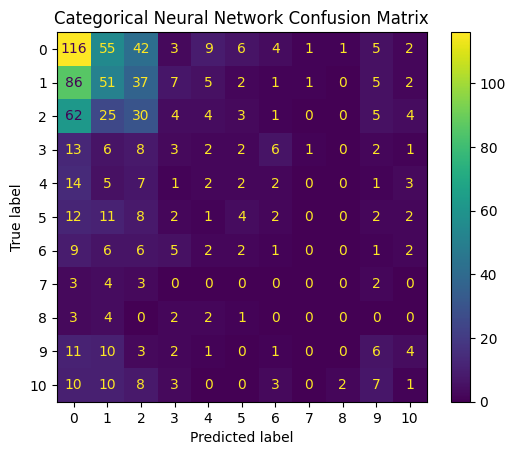

In [105]:
# create confusion matrix
# get prediction values
predictions = model.predict(Testing_Data)
Model_Results = np.argmax(predictions, axis = 1)

# transform classes back to labels
Model_Transform = np.argmax(Testing_Label, axis=1)

# Create confusion matrix
CM_NN = confusion_matrix(Model_Transform, Model_Results)

# print
print('Model 2 Confusion matrix:', CM_NN)

# display
disp1 = ConfusionMatrixDisplay(confusion_matrix=CM_NN)
disp1.plot()
plt.title("Categorical Neural Network Confusion Matrix")

plt.show()

In [109]:
# Get Model Accuracy score
print('The Neural Network accuracy is:', accuracy_score(Model_Results, Model_Transform))

The Neural Network accuracy is: 0.25355450236966826


In [110]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [111]:
# Retry classification model with base master dataset
from nltk.tokenize import word_tokenize
# First, tokenize the content column with nltk
master_df['tokens'] = master_df['Content'].apply(word_tokenize)

In [112]:
# download stopwords
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [113]:
stop_words = set(stopwords.words('english'))

In [114]:
# remove stop words from Content column
master_df['clean_tokens'] = master_df['Content'].apply(
    lambda text: [w for w in word_tokenize(text.lower()) if w.isalpha() and w not in stop_words]
)

In [116]:
# Intantiate Stemmer and Lemmer
STEMMER=PorterStemmer()
LEMMER = WordNetLemmatizer()

In [117]:
# Stem the data as a new column in a the dataframe


master_df['Stemmed'] = master_df['clean_tokens'].apply(lambda x: [STEMMER.stem(word) for word in x])

# Lemmatize the data too
master_df['Lemmed'] = master_df['clean_tokens'].apply(lambda x: [LEMMER.lemmatize(word) for word in x])

In [118]:
# check results
master_df.head()

,LABEL,Content,tokens,clean_tokens,Stemmed,Lemmed
0,universal healthcare,universal basic income offers strings attached...,"[universal, basic, income, offers, strings, at...","[universal, basic, income, offers, strings, at...","[univers, basic, incom, offer, string, attach,...","[universal, basic, income, offer, string, atta..."
1,universal healthcare,universal basic income politically controversi...,"[universal, basic, income, politically, contro...","[universal, basic, income, politically, contro...","[univers, basic, incom, polit, controversi, wa...","[universal, basic, income, politically, contro..."
2,universal healthcare,senators grilled robert kennedy trump pick hea...,"[senators, grilled, robert, kennedy, trump, pi...","[senators, grilled, robert, kennedy, trump, pi...","[senat, grill, robert, kennedi, trump, pick, h...","[senator, grilled, robert, kennedy, trump, pic..."
3,universal healthcare,health secretary says reform poverty ambition ...,"[health, secretary, says, reform, poverty, amb...","[health, secretary, says, reform, poverty, amb...","[health, secretari, say, reform, poverti, ambi...","[health, secretary, say, reform, poverty, ambi..."
4,universal healthcare,initiative follows pressure from several artis...,"[initiative, follows, pressure, from, several,...","[initiative, follows, pressure, several, artis...","[initi, follow, pressur, sever, artist, chappe...","[initiative, follows, pressure, several, artis..."


In [122]:
# Note: Initially tried to use stemmed/lemmatized data, but realized it was more useful to map tokenized data instead

In [123]:
# Rejoin tokens for Tensorflow tokenizer
master_df['Tokens Joined'] = master_df['clean_tokens'].apply(lambda tokens: ' '.join(tokens))

In [124]:
# Tokenize with Tensorflow
tokenizer = Tokenizer(num_words=100000, oov_token='<OOV>')
tokenizer.fit_on_texts(master_df['Tokens Joined'])
word_index = tokenizer.word_index

In [125]:
# Create an embedding list

nlp = spacy.load('en_core_web_md')

text_embedding = np.zeros((len(word_index) + 1, 300))
for word, i in word_index.items():
   text_embedding[i] = nlp(word).vector

In [126]:
# Sequences 2
sequences2 = tokenizer.texts_to_sequences(master_df['Tokens Joined'])

padding2 = pad_sequences(sequences2, padding='post', maxlen=100)

HotEncoder = OneHotEncoder(sparse_output = False) # No sparse matrix format
OneHotLabels = HotEncoder.fit_transform(master_df[['LABEL']])

In [127]:
# Create new train/test set of data
Training_Data2, Testing_Data2, Training_Label2, Testing_Label2 = train_test_split(padding2, OneHotLabels, test_size= 0.3, random_state = 340)

# check results
print('Training Data:', Training_Data)
print('Training Labels:', Training_Label)

print('Testing Data:', Testing_Data)
print('Testing Labels:', Testing_Label)

Training Data: [[ 2  9  3 ...  0  0  0]
 [18  2  2 ...  3 13  2]
 [ 2 12 17 ...  3 11  2]
 ...
 [ 6 10  7 ...  9  3  2]
 [ 2 13  3 ...  6  5  2]
 [ 2 18 10 ...  0  0  0]]
Training Labels: [[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
Testing Data: [[ 2  2 16 ...  5  8  2]
 [22  3  7 ...  4 13  2]
 [ 3  2  2 ...  6 11  2]
 ...
 [ 2  3  5 ...  0  0  0]
 [ 2 18 10 ...  9  3  2]
 [ 4 19  2 ...  9  8  2]]
Testing Labels: [[0. 0. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [128]:
# Create the new model

# set number of classes to classify
classes = 11 # Got from TrainingLabels.shape[1]

vocab_size = 100000  # tokenizer max words
embedding_dim = 128



model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(classes, activation='softmax')  # softclass activation for mutliclassification
])

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model2.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [129]:
# Fit the model
model2.fit(Training_Data2, Training_Label2, validation_data= (Testing_Data2, Testing_Label2), epochs = 100, batch_size = 32)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 281ms/step - accuracy: 0.3049 - loss: 2.1953 - val_accuracy: 0.3175 - val_loss: 2.0604
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 14s 302ms/step - accuracy: 0.3591 - loss: 2.0048 - val_accuracy: 0.3144 - val_loss: 2.0007
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 267ms/step - accuracy: 0.3614 - loss: 1.9245 - val_accuracy: 0.3223 - val_loss: 1.9194
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 241ms/step - accuracy: 0.3409 - loss: 1.8565 - val_accuracy: 0.3223 - val_loss: 1.8596
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.3654 - loss: 1.7442 - val_accuracy: 0.3365 - val_loss: 1.8022
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.3933 - loss: 1.6672 - val_accuracy: 0.3507 - val_loss: 1.7261
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 211ms/step - accuracy: 0.3959 - loss: 1.5993 - val_accuracy: 0.3649 - val_loss: 1.6672
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 215ms/step - accuracy: 0.4501 - loss: 1.4631 - va

In [130]:
# Get accuracy and loss

loss2, accuracy2 = model2.evaluate(Testing_Data2, Testing_Label2)
print('Second Model Accuracy:', accuracy2)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5048 - loss: 2.4060
Second Model Accuracy: 0.5071089863777161


In [133]:
# Create confusion matrix

# get prediction values
predictions2 = model2.predict(Testing_Data2)
Model2_Results = np.argmax(predictions2, axis=1)

# transform classes back to labels
Model2_Transform = np.argmax(Testing_Label2, axis=1)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [134]:
# Create confusion matrix
CM_NN2 = confusion_matrix(Model2_Transform, Model2_Results)

In [135]:
# print
print('Model 2 Confusion matrix:', CM_NN2)

Model 2 Confusion matrix: [[149  15  18   0   0   0   2   0   0   0   0]
 [ 40  76  22   0   0   0   1   0   0   1   0]
 [ 38  24  48   1   0   0   0   0   0   0   0]
 [  7   0   2  11   0   3   4   0   0   0   0]
 [  6   1   3   8   3   3   2   0   0   1   1]
 [  2   0   2   7   3  14   3   1   0   0   2]
 [  6   2   3   6   0   4   6   0   0   0   2]
 [  2   0   1   3   0   0   2   0   0   1   1]
 [  5   1   1   0   1   0   2   0   1   0   0]
 [  2   2   2   3   0   1   5   0   0  11   2]
 [  4   1   2   8   0   2   4   0   1   7   2]]


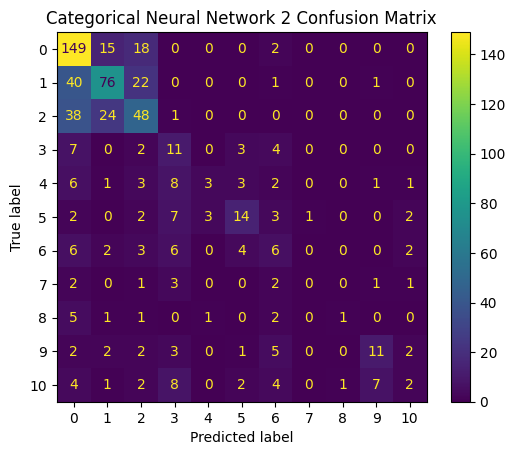

In [136]:
# display
disp2 = ConfusionMatrixDisplay(confusion_matrix=CM_NN2)
disp2.plot()
plt.title("Categorical Neural Network 2 Confusion Matrix")

plt.show()

In [137]:
# Get Model Accuracy score
print('The Neural Network 2 accuracy is:', accuracy_score(Model2_Results, Model2_Transform))

The Neural Network 2 accuracy is: 0.5071090047393365
